## Wisdom of Crowds

The author mentions an experiment by Francis Galton.  
The point is: each individual person can be wrong, but if you take the median  
of the answers of many people - hundreds, it turns out to be surprisingly accurate.  
This brings us to the concept of central tendency  

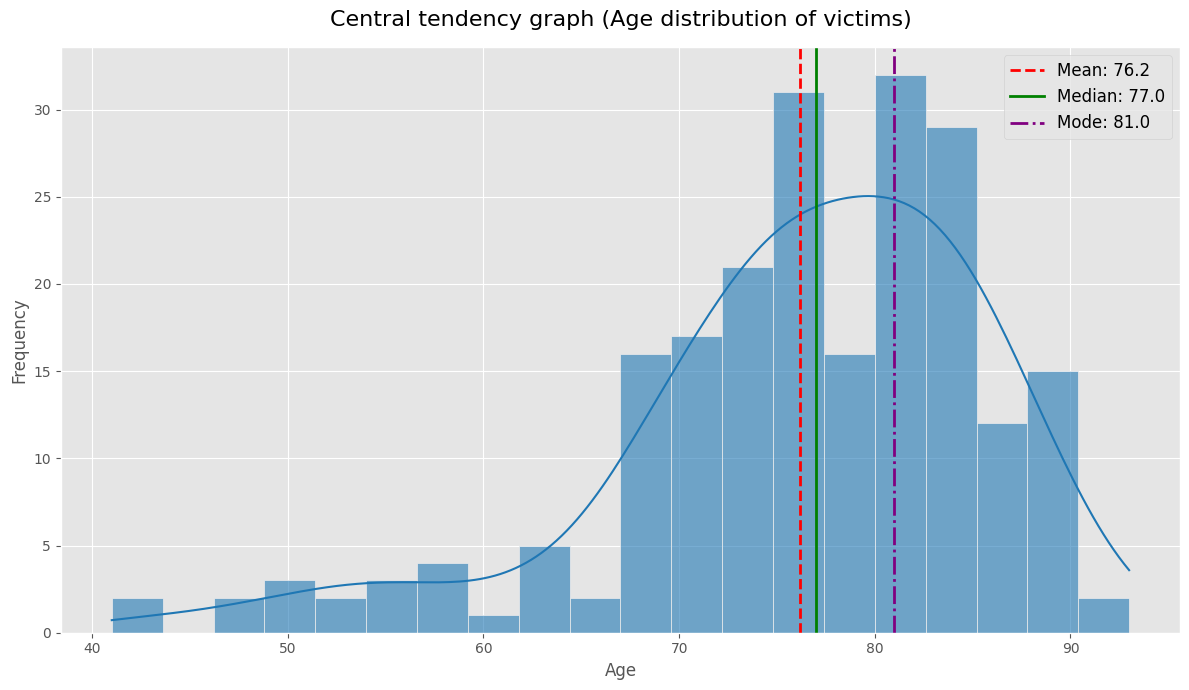

In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

folder_path = os.path.join("..", "introduction")
file_name = "shipman-confirmed-victims.csv"
file_path = os.path.join(folder_path, file_name)
df = pd.read_csv(file_path)


ages = df['Age'].dropna()


mean_age = ages.mean()
median_age = ages.median()
mode_age = ages.mode().iloc[0] 

plt.figure(figsize=(12, 7))


sns.histplot(ages, kde=True, color='#1f77b4', bins=20, alpha=0.6)

plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_age:.1f}')
plt.axvline(median_age, color='green', linestyle='-', linewidth=2, 
            label=f'Median: {median_age:.1f}')
plt.axvline(mode_age, color='purple', linestyle='-.', linewidth=2, 
            label=f'Mode: {mode_age:.1f}')

plt.title('Central tendency graph (Age distribution of victims)', fontsize=16, pad=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=12)

plt.tight_layout()

plt.show()

## Location

Mean - sensitive to outliers  
Median - a fair middle, indifferent to extreme values - outliers  
Standard Deviation - although most people intuitively think of it as a quantity  
that shows how far the values ​​are spread out from the mean,  
this quantity includes the square of the difference which makes it less intuitive  
in the case of non-normally distributed values  
IQR - interquartile range, the distance between the 25th and 75th percentiles.  

## Sexual Partners and Skewness

The example of the number of sexual partners in the British perfectly illustrates  
skewed data  
most people do not have a large number of partners, but there are a few  
extremes, outliers - in which there are hundreds  
Conclusion: the average value - mean, becomes much higher than the median.  
If you say: "On average, people have 15 partners", this will be mathematically true,  
but false for 80% of the population.

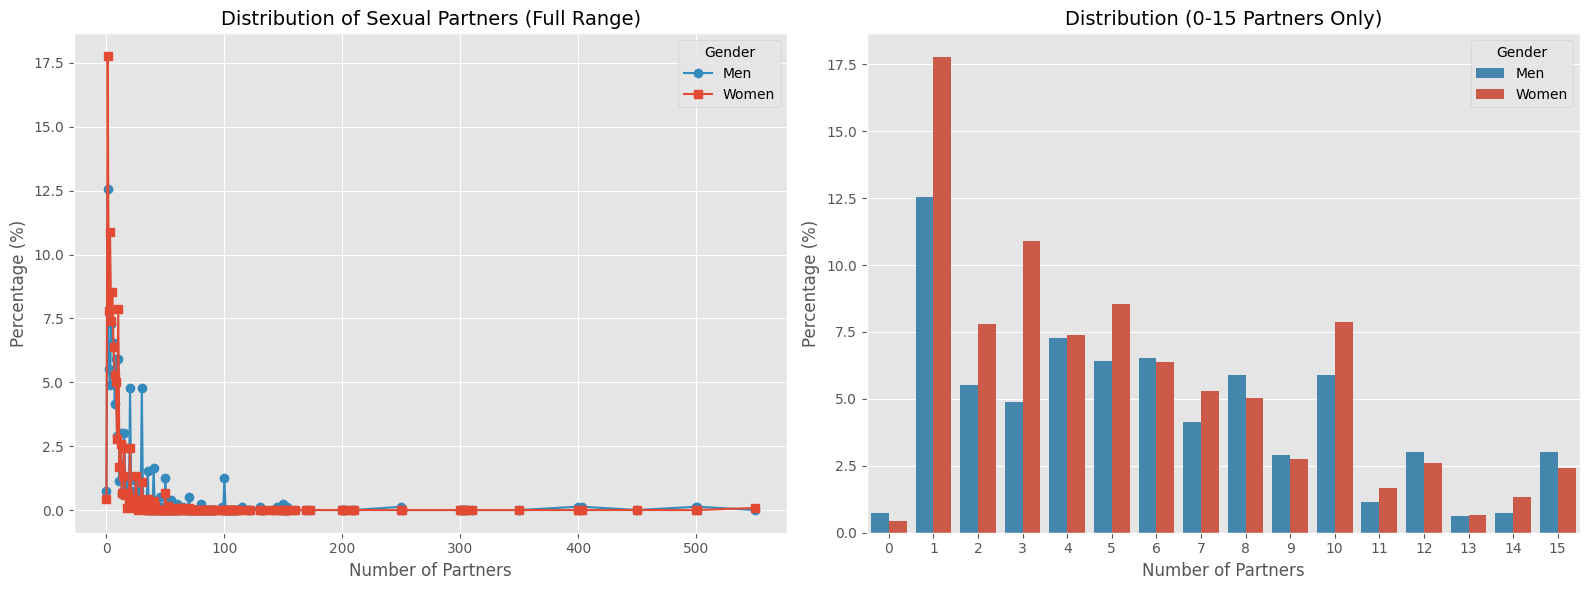

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# Load the provided dataset
df = pd.read_csv('sexual-partners-counts-x.csv')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# PLOT 1: Line chart for the full range of data
axes[0].plot(df['NumPartners'], df['MenPercent'], marker='o', label='Men', color='#348ABD')
axes[0].plot(df['NumPartners'], df['WomenPercent'], marker='s', label='Women', color='#E24A33')

axes[0].set_title('Distribution of Sexual Partners (Full Range)', fontsize=14)
axes[0].set_xlabel('Number of Partners', fontsize=12)
axes[0].set_ylabel('Percentage (%)', fontsize=12)
axes[0].legend(title='Gender')

# PLOT 2: Bar chart for up to 15 partners
df_filtered = df[df['NumPartners'] <= 15]


df_melted = df_filtered.melt(
    id_vars='NumPartners', 
    value_vars=['MenPercent', 'WomenPercent'], 
    var_name='Gender', 
    value_name='Percent'
)

df_melted['Gender'] = df_melted['Gender'].map({'MenPercent': 'Men', 'WomenPercent': 'Women'})


sns.barplot(
    data=df_melted, 
    x='NumPartners', 
    y='Percent', 
    hue='Gender', 
    palette=['#348ABD', '#E24A33'],
    ax=axes[1]
)

axes[1].set_title('Distribution (0-15 Partners Only)', fontsize=14)
axes[1].set_xlabel('Number of Partners', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(title='Gender')

plt.tight_layout()

plt.show()

## Visualization

See, not just count  

Histograms: Show the shape of a distribution.  

Box-and-whisker plots: Great for showing medians, quartiles, and outliers.  

Scatter-plots: Used to find the relationship between two variables  
(e.g., hospital occupancy and survival).

## Finding connections and trends

Correlation: Does one variable change when another changes?   
(For example, does the popularity of your name decrease over time?)  

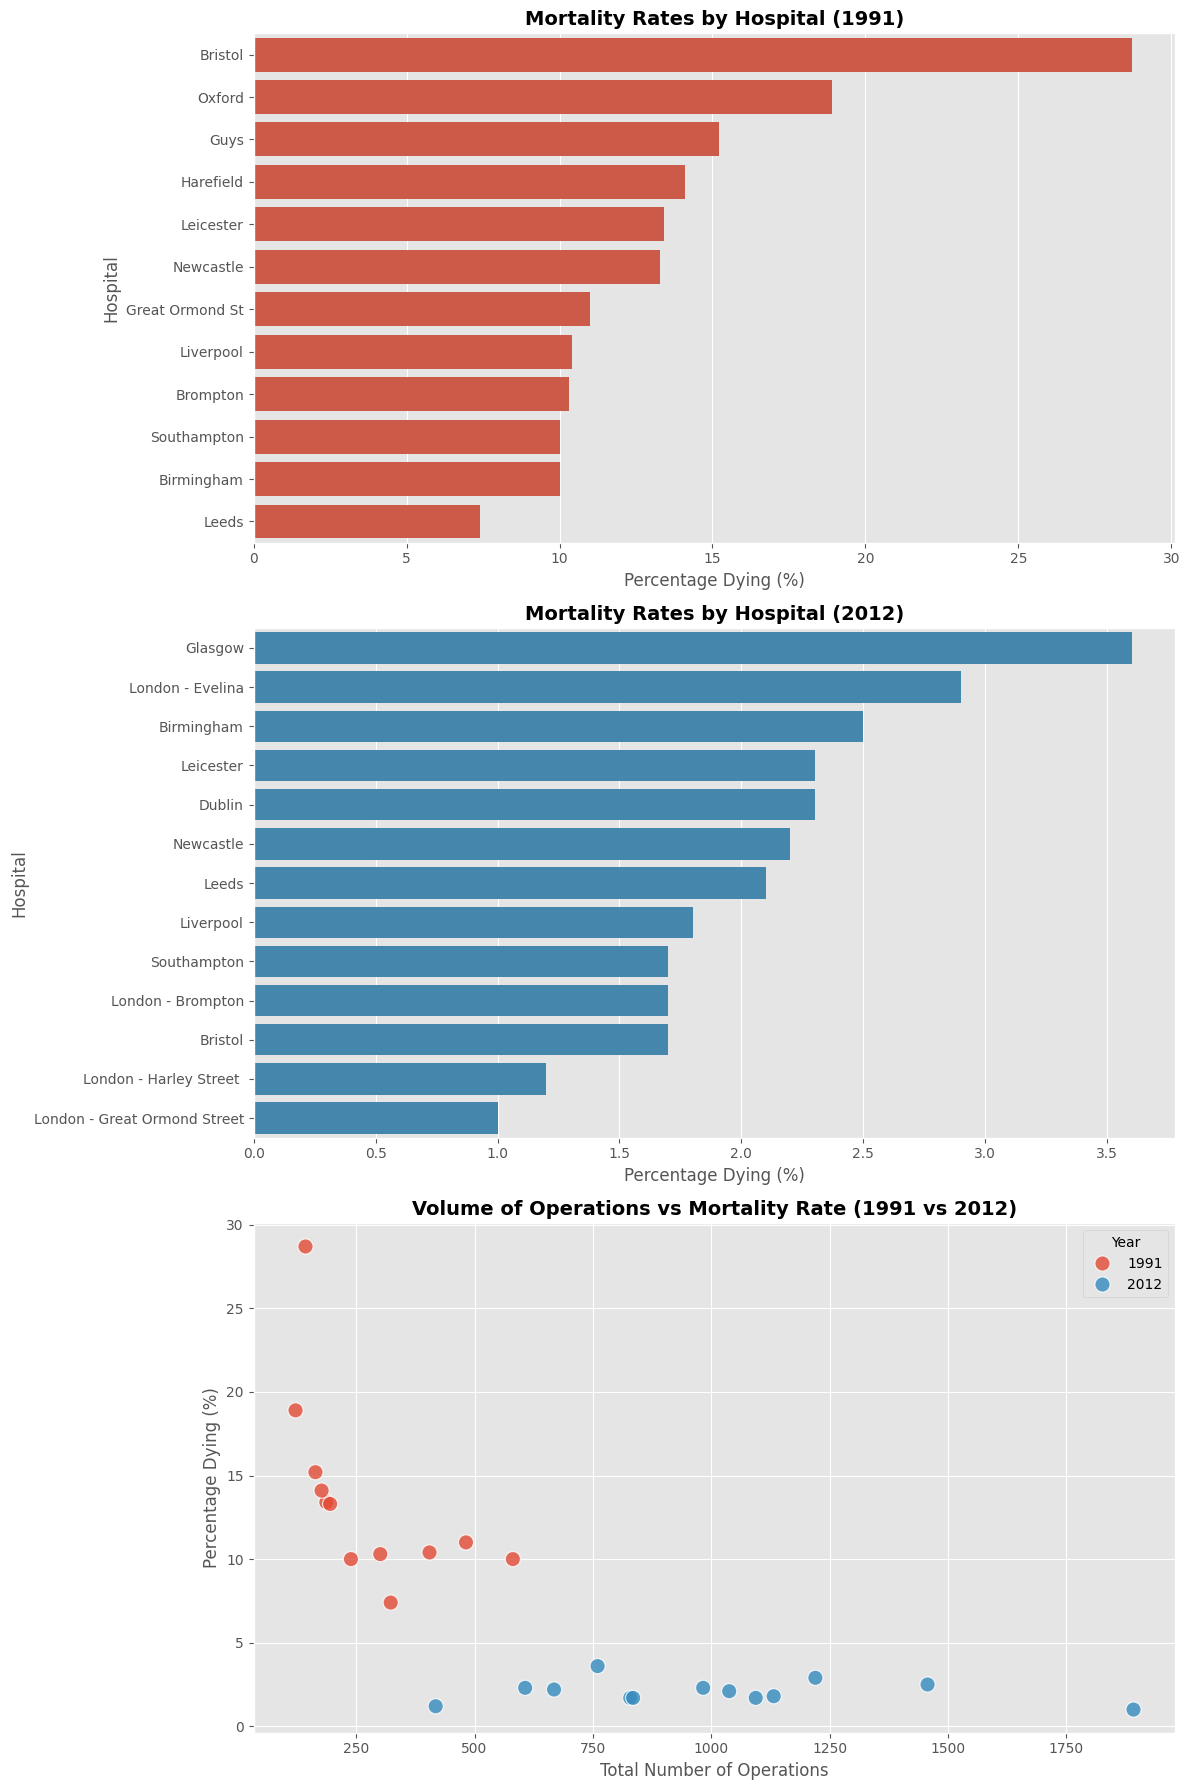

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set ggplot style for an R-like appearance
plt.style.use('ggplot')

# Load both datasets
df_1991 = pd.read_csv('child-heart-surgery-1991-x.csv')
df_2012 = pd.read_csv('child-heart-surgery-2012-x.csv')

df_1991['Year'] = '1991'
df_2012['Year'] = '2012'


df_combined = pd.concat([df_1991, df_2012], ignore_index=True)

df_1991_sorted = df_1991.sort_values('PercentageDying', ascending=False)
df_2012_sorted = df_2012.sort_values('PercentageDying', ascending=False)

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# PLOT 1: Mortality Rates by Hospital in 1991
sns.barplot(
    data=df_1991_sorted, 
    x='PercentageDying', 
    y='Hospital', 
    color='#E24A33', # Red color
    ax=axes[0]
)
axes[0].set_title('Mortality Rates by Hospital (1991)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Percentage Dying (%)', fontsize=12)
axes[0].set_ylabel('Hospital', fontsize=12)


# PLOT 2: Mortality Rates by Hospital in 2012
sns.barplot(
    data=df_2012_sorted, 
    x='PercentageDying', 
    y='Hospital', 
    color='#348ABD', 
    ax=axes[1]
)
axes[1].set_title('Mortality Rates by Hospital (2012)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Percentage Dying (%)', fontsize=12)
axes[1].set_ylabel('Hospital', fontsize=12)


# PLOT 3: Operations Volume vs Mortality Rate (Scatter Plot)
sns.scatterplot(
    data=df_combined, 
    x='Operations', 
    y='PercentageDying', 
    hue='Year', 
    palette=['#E24A33', '#348ABD'], 
    s=120, 
    alpha=0.8,
    edgecolor='white',
    ax=axes[2]
)
axes[2].set_title('Volume of Operations vs Mortality Rate (1991 vs 2012)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Total Number of Operations', fontsize=12)
axes[2].set_ylabel('Percentage Dying (%)', fontsize=12)
axes[2].legend(title='Year')

plt.tight_layout()

plt.show()

## Communication and Storytelling

Statistics without context are just noise.

Infographics: They should guide the viewer through the story, but the author warns:  
don't make it too complicated ("chartjunk") so as not to confuse people.

## Summary:

Outliers: One very large number can "break" the mean, but will not affect the median.  

Transformations: Sometimes data needs to be logarithmized or scaled to see patterns that were hidden.  

Simplification: Any generalization (e.g. "average salary") always hides details.  
It is important to know what details we have lost.